In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df=pd.read_csv("/home/asad-shareef/Personel/Nothing/final_THP.csv")
df=df[df["crop"]=="wheat"]
df=df.sort_values(by=["district","crop"])
df["flag"]=df["kg/acre"]==0
df

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,veg_prec,flow_prec,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag
1,attock,1981,wheat,19.43,13.58,11.05,13.90,54.34,63.23,56.60,55.31,14.34,34.45,92.56,58.41,1.538567,16.76787,7.54444,331.578947,False
4,attock,1982,wheat,18.05,13.87,11.85,10.37,29.82,35.65,43.78,60.83,10.91,8.13,23.17,222.06,1.538567,16.76787,7.54444,402.024291,False
7,attock,1983,wheat,18.19,11.68,10.73,13.05,38.99,53.58,49.26,50.46,55.39,40.42,37.51,28.24,1.538567,16.76787,7.54444,351.821862,False
10,attock,1984,wheat,18.36,13.30,10.95,10.79,22.70,33.30,32.85,45.32,1.61,1.68,4.15,40.01,1.538567,16.76787,7.54444,373.684211,False
13,attock,1985,wheat,17.59,11.72,10.76,15.50,32.51,37.92,48.24,26.25,9.70,13.73,5.94,7.03,1.538567,16.76787,7.54444,535.627530,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,vehari,2020,wheat,20.28,14.28,11.84,16.89,49.43,40.85,58.93,45.56,14.94,9.01,32.43,3.45,1.546484,9.56018,7.59187,1412.145749,False
3685,vehari,2021,wheat,19.27,13.87,12.52,17.85,38.57,58.52,53.35,46.25,420.29,7.88,13.96,0.03,1.546484,9.56018,7.59187,1410.931174,False
3688,vehari,2022,wheat,21.42,15.43,13.51,16.82,25.76,30.07,57.59,45.90,0.00,0.48,42.10,0.87,1.546484,9.56018,7.59187,1505.263158,False
3691,vehari,2023,wheat,22.11,17.27,12.51,20.28,36.05,31.71,33.33,28.21,3.68,1.14,2.60,0.85,1.546484,9.56018,7.59187,1628.340081,False


In [3]:
low=df["kg/acre"].quantile(0.01)
high=df["kg/acre"].quantile(0.99)
df=df[(df["kg/acre"]>=low)&(df["kg/acre"]<=high)]

In [4]:
df["soil"]=df["n__g/kg"]+df["soc__g/kg"]
df["total_prec"]=df["germ_prec"]+df["veg_prec"]+df["flow_prec"]+df["fruit_prec"]
df["avg_rh"]=(df["germ_rh"]+df["veg_rh"]+df["flow_rh"]+df["fruit_rh"])/4

In [5]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'germ_prec',
       'veg_prec', 'flow_prec', 'fruit_prec', 'n__g/kg', 'soc__g/kg',
       'soil_ph', 'kg/acre', 'flag', 'soil', 'total_prec', 'avg_rh'],
      dtype='str')

In [6]:
dfc=df.drop(["district","crop"],axis=1)

In [7]:
dfc.corr()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,...,flow_prec,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag,soil,total_prec,avg_rh
year,1.000000,-0.089605,-0.000740,-0.123608,0.137838,0.379004,0.023734,0.176656,0.179114,0.164545,...,0.167395,0.008005,0.003545,0.007454,-0.003525,0.637893,-0.244602,0.007200,0.092201,0.232554
germ_temp,-0.089605,1.000000,0.707915,0.618146,0.342640,-0.564470,-0.520558,-0.439369,-0.415971,-0.298400,...,-0.332119,-0.352212,-0.409518,-0.590310,0.257039,0.267033,-0.035426,-0.581043,-0.513439,-0.597445
veg_temp,-0.000740,0.707915,1.000000,0.635207,0.408502,-0.577842,-0.579085,-0.343904,-0.395501,-0.266259,...,-0.167179,-0.344853,-0.277653,-0.421598,0.158306,0.256427,-0.070385,-0.413729,-0.457829,-0.587458
flow_temp,-0.123608,0.618146,0.635207,1.000000,0.565888,-0.459353,-0.412863,-0.549962,-0.474168,-0.178570,...,-0.401791,-0.309861,-0.325680,-0.492938,0.187834,0.188936,-0.018312,-0.483826,-0.463785,-0.578898
fruit_temp,0.137838,0.342640,0.408502,0.565888,1.000000,-0.186901,-0.182948,-0.253418,-0.562260,0.035537,...,-0.295571,-0.387842,-0.329244,-0.470564,0.189767,0.365872,-0.066115,-0.463414,-0.369401,-0.365154
germ_rh,0.379004,-0.564470,-0.577842,-0.459353,-0.186901,1.000000,0.735882,0.505618,0.472035,0.344468,...,0.324956,0.318169,0.193511,0.296144,-0.144800,0.076066,0.020661,0.290488,0.507727,0.839630
veg_rh,0.023734,-0.520558,-0.579085,-0.412863,-0.182948,0.735882,1.000000,0.539420,0.474687,0.382074,...,0.250867,0.310268,0.156864,0.249404,-0.108864,-0.149349,0.104838,0.244126,0.560739,0.851031
flow_rh,0.176656,-0.439369,-0.343904,-0.549962,-0.253418,0.505618,0.539420,1.000000,0.571071,0.247948,...,0.718569,0.255769,0.238859,0.377895,-0.169309,-0.045216,0.065878,0.369997,0.587279,0.789243
fruit_rh,0.179114,-0.415971,-0.395501,-0.474168,-0.562260,0.472035,0.474687,0.571071,1.000000,0.133605,...,0.519583,0.592801,0.293896,0.447035,-0.195490,-0.117490,0.028680,0.438648,0.664919,0.774537
germ_prec,0.164545,-0.298400,-0.266259,-0.178570,0.035537,0.344468,0.382074,0.247948,0.133605,1.000000,...,0.095817,0.109813,0.097496,0.110216,-0.047615,0.053518,-0.001668,0.110261,0.516855,0.341628


In [8]:
df=df.drop([ 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'n__g/kg', 'soc__g/kg','avg_rh'],axis=1)

<Axes: xlabel='total_prec', ylabel='kg/acre'>

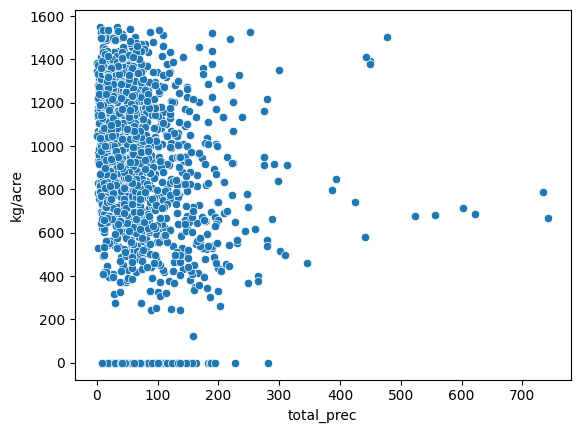

In [9]:
sns.scatterplot(x="total_prec",y="kg/acre",data=df)

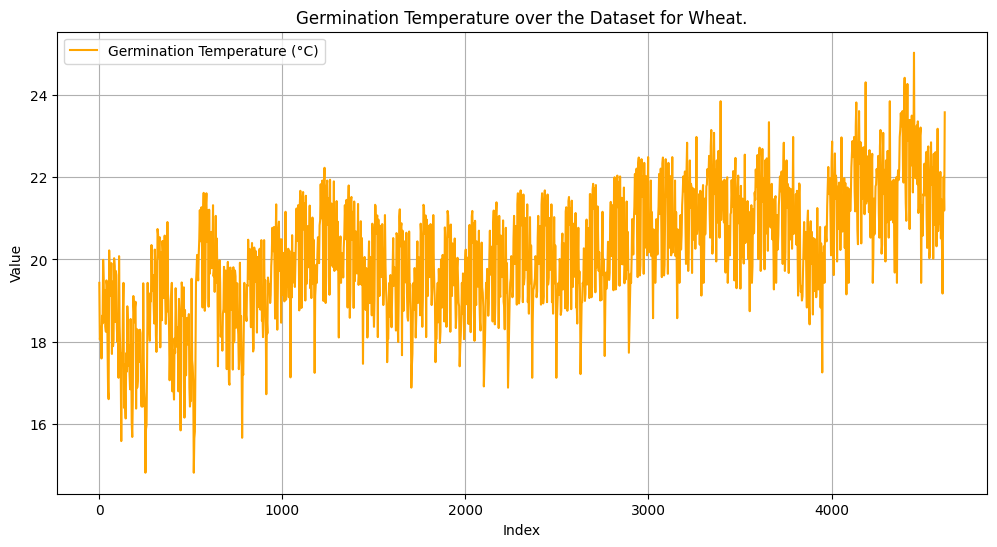

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=df.index, y='germ_temp', label='Germination Temperature (°C)',color='orange')
# sns.lineplot(data=df, x=df.index, y='soil_ph', label='Soil pH')
# sns.lineplot(data=df, x=df.index, y='soil', label='Soil_Nitrogen_SOC')
# sns.lineplot(data=df, x=df.index, y='kg/acre', label='Yield (tons/ha)')
plt.title("Germination Temperature over the Dataset for Wheat.")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

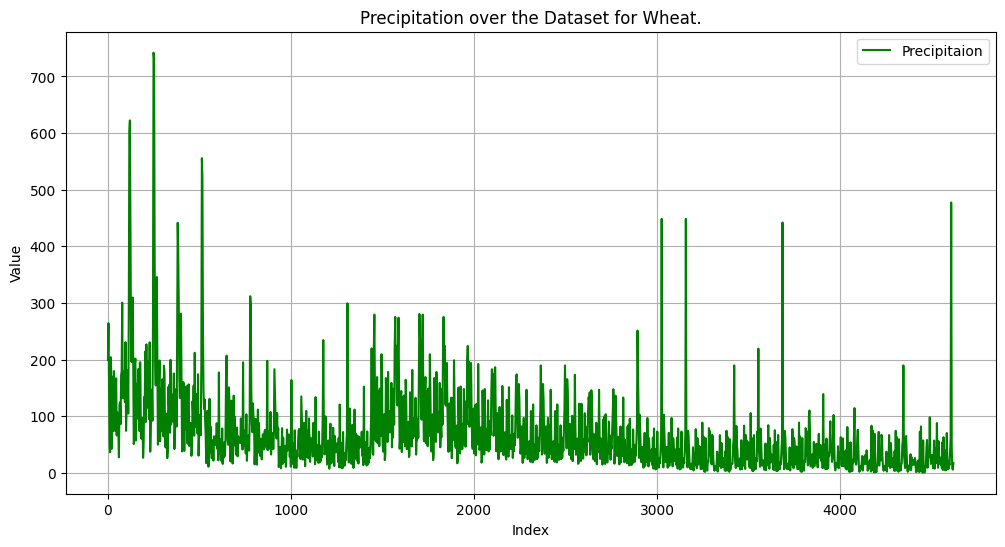

In [11]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=df.index, y='total_prec', label='Precipitaion',color='green')
plt.title("Precipitation over the Dataset for Wheat.")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
df["water_stress"]=df["total_prec"]>500

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 1524 entries, 1 to 3694
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   district      1524 non-null   str    
 1   year          1524 non-null   int64  
 2   crop          1524 non-null   str    
 3   germ_temp     1524 non-null   float64
 4   veg_temp      1524 non-null   float64
 5   flow_temp     1524 non-null   float64
 6   fruit_temp    1524 non-null   float64
 7   germ_prec     1524 non-null   float64
 8   veg_prec      1524 non-null   float64
 9   flow_prec     1524 non-null   float64
 10  fruit_prec    1524 non-null   float64
 11  soil_ph       1524 non-null   float64
 12  kg/acre       1524 non-null   float64
 13  flag          1524 non-null   bool   
 14  soil          1524 non-null   float64
 15  total_prec    1524 non-null   float64
 16  water_stress  1524 non-null   bool   
dtypes: bool(2), float64(12), int64(1), str(2)
memory usage: 214.1 KB


In [14]:
df.describe()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,soil,total_prec
count,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000
mean,2002.313648,20.130269,14.959449,12.940538,15.872192,9.131719,11.729259,19.117277,29.125722,7.644175,924.916425,12.276622,69.103976
std,12.621155,1.490708,1.484399,1.416451,1.943749,28.252340,17.198820,24.689209,41.493661,0.333901,342.965741,4.318814,71.857158
min,1981.000000,14.810000,10.700000,8.620000,9.800000,0.000000,0.000000,0.000000,0.000000,6.358080,0.000000,6.985000,0.360000
25%,1991.000000,19.190000,13.920000,11.977500,14.550000,0.260000,0.437500,2.605000,5.957500,7.555000,719.028340,9.138000,23.452500
50%,2002.000000,20.135000,14.920000,12.900000,15.960000,2.105000,4.530000,10.115000,15.460000,7.711910,948.424041,11.541315,49.985000
75%,2013.000000,21.190000,15.972500,13.930000,17.120000,9.660000,16.767500,27.100000,36.745000,7.878000,1185.020243,13.754063,87.265000
max,2024.000000,25.030000,20.200000,17.790000,22.720000,455.140000,188.720000,174.690000,576.600000,8.030080,1551.012146,28.791581,741.930000


In [15]:
df["district"].value_counts()

district
attock             44
bhakkar            44
bhawalnagar        44
chakwal            44
dera ghazi khan    44
faisalabad         44
gujranwala         44
gujrat             44
jhang              44
jhelum             44
khushab            44
lahore             44
layyah             44
mandi bahauddin    44
mianwali           44
muzaffargarh       44
narowal            44
rawalpindi         44
sargodha           44
sheikhupura        44
sialkot            44
toba tek singh     44
bahawalpur         43
hafizabad          43
kasur              43
khanewal           43
multan             43
nankana sahib      43
rahim yar khan     43
rajanpur           43
sahiwal            43
vehari             43
lodhran            42
okara              42
pakpattan          42
Name: count, dtype: int64

In [16]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_prec', 'veg_prec', 'flow_prec', 'fruit_prec',
       'soil_ph', 'kg/acre', 'flag', 'soil', 'total_prec', 'water_stress'],
      dtype='str')

In [17]:
cat_col=["district",'crop']
num_col=[ 'year','germ_temp', 'veg_temp', 'flow_temp', 'fruit_temp',
         'soil_ph','soil','total_prec','germ_prec', 'veg_prec',
       'flow_prec', 'fruit_prec']

In [18]:
df=pd.get_dummies(df,columns=cat_col)

In [19]:
df

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_wheat
1,1981,19.43,13.58,11.05,13.90,14.34,34.45,92.56,58.41,7.54444,...,False,False,False,False,False,False,False,False,False,True
4,1982,18.05,13.87,11.85,10.37,10.91,8.13,23.17,222.06,7.54444,...,False,False,False,False,False,False,False,False,False,True
7,1983,18.19,11.68,10.73,13.05,55.39,40.42,37.51,28.24,7.54444,...,False,False,False,False,False,False,False,False,False,True
10,1984,18.36,13.30,10.95,10.79,1.61,1.68,4.15,40.01,7.54444,...,False,False,False,False,False,False,False,False,False,True
13,1985,17.59,11.72,10.76,15.50,9.70,13.73,5.94,7.03,7.54444,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,2019,21.47,15.04,12.65,14.45,0.06,7.57,16.90,16.34,7.59187,...,False,False,False,False,False,False,False,False,True,True
3682,2020,20.28,14.28,11.84,16.89,14.94,9.01,32.43,3.45,7.59187,...,False,False,False,False,False,False,False,False,True,True
3685,2021,19.27,13.87,12.52,17.85,420.29,7.88,13.96,0.03,7.59187,...,False,False,False,False,False,False,False,False,True,True
3688,2022,21.42,15.43,13.51,16.82,0.00,0.48,42.10,0.87,7.59187,...,False,False,False,False,False,False,False,False,True,True


In [20]:
x=df.drop("kg/acre",axis=1)
y=df["kg/acre"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0,shuffle=True)

In [23]:
x_train

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_wheat
3853,1989,20.16,15.53,11.65,14.30,0.73,14.55,6.02,1.14,7.74795,...,False,False,False,False,False,False,False,False,False,True
3820,2022,21.27,15.57,13.72,17.15,0.00,1.59,27.88,0.65,7.55500,...,False,False,False,False,False,False,False,False,False,True
1741,1989,18.94,15.65,11.74,14.44,3.92,53.52,33.58,15.34,7.20303,...,False,False,False,False,False,False,True,False,False,True
1249,2001,20.84,15.52,12.52,16.51,2.19,25.91,22.58,0.73,7.84247,...,False,False,False,False,False,False,False,True,False,True
2551,1995,21.27,14.75,12.22,15.17,0.30,14.00,42.73,116.14,6.35808,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,2000,23.08,17.53,15.09,15.50,0.01,0.00,8.08,2.00,7.68558,...,False,False,False,False,False,False,False,False,False,True
808,1986,19.38,13.63,11.06,13.15,1.55,46.36,3.67,43.71,7.73821,...,False,False,False,False,False,False,False,False,False,True
4216,2022,22.12,16.32,14.32,18.28,0.00,1.31,30.84,1.60,7.98215,...,False,True,False,False,False,False,False,False,False,True
2743,2015,19.01,13.64,12.51,16.55,9.22,1.48,18.45,36.70,7.69263,...,False,False,False,False,False,False,False,False,False,True


In [24]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
ss=StandardScaler()
mm=MinMaxScaler()

In [25]:
# x_train[num_col]=ss.fit_transform(x_train[num_col])
# x_test[num_col]=ss.transform(x_test[num_col])

In [26]:
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

In [27]:
dtr=DecisionTreeRegressor()
rfr=RandomForestRegressor()
gbr=GradientBoostingRegressor(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8,
    min_weight_fraction_leaf=0.0,
    min_samples_leaf=2,
    random_state=0,
    min_samples_split=0.01
)
xgb=XGBRegressor(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8
)

In [37]:
dtr.fit(x_train,y_train)
# dtr_pred=dtr.predict(x_test)
# dtr_pred_t=dtr.predict(x_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

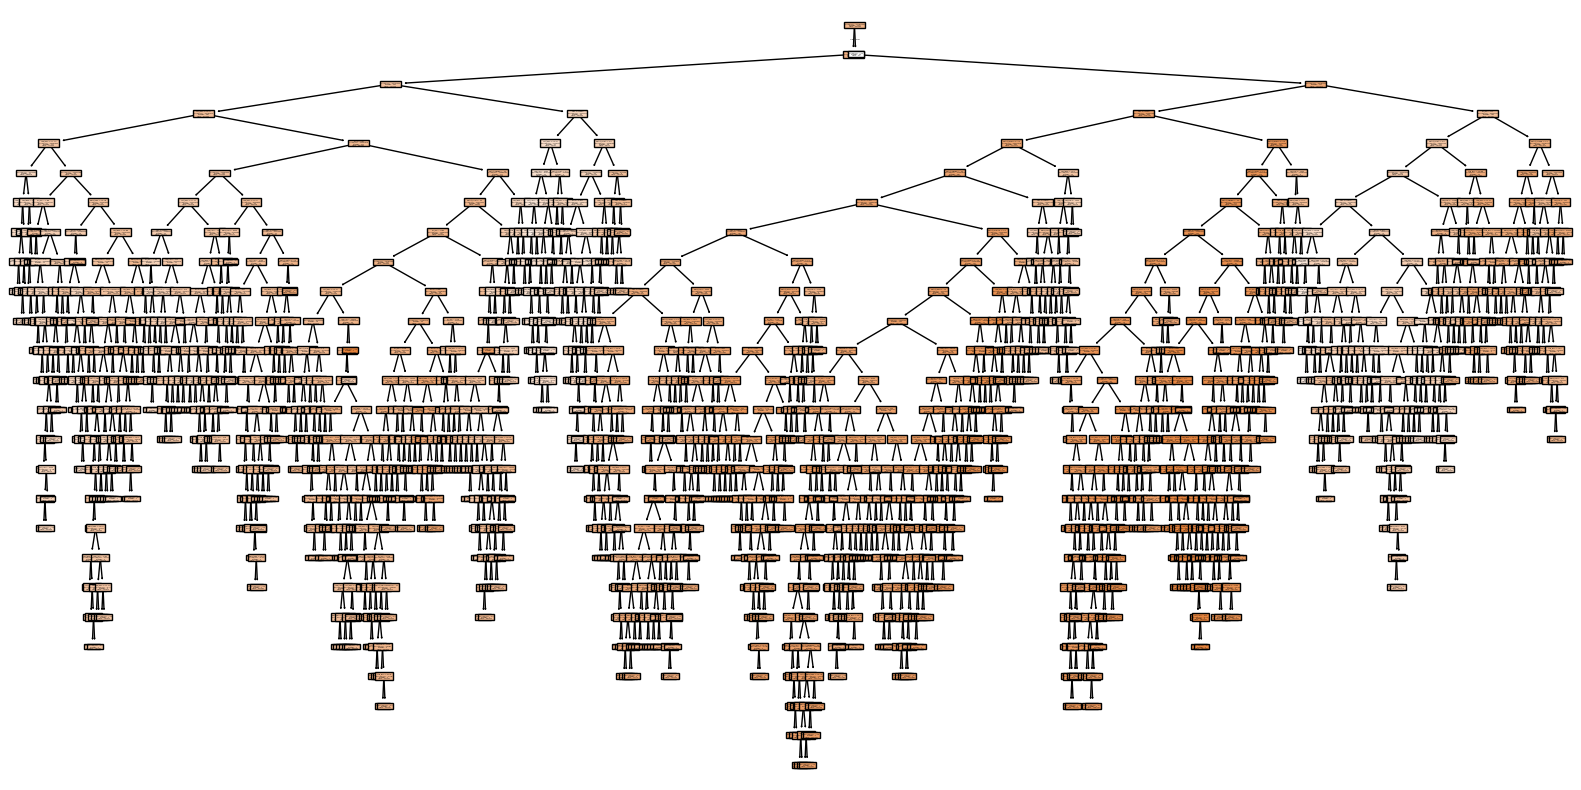

In [36]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    dtr,
    filled=True,
    feature_names=x.columns
)
plt.show()

In [33]:
rfr.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
rfr_pred=rfr.predict(x_test)
rfr_pred_t=rfr.predict(x_train)

In [35]:
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",800
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",0.01
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in the

In [36]:
gbr_pred=gbr.predict(x_test)
gbr_pred_t=gbr.predict(x_train)

In [37]:
xgb.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [38]:
xgb_pred=xgb.predict(x_test)
xgb_pred_t=xgb.predict(x_train)

In [39]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [40]:
print("r2_gbr_t=",r2_score(y_train,gbr_pred_t))
print("r2_xgb_t=",r2_score(y_train,xgb_pred_t))
print("r2_rfr_t=",r2_score(y_train,rfr_pred_t))
print("r2_dtr_t=",r2_score(y_train,dtr_pred_t))

r2_gbr_t= 0.998071579409214
r2_xgb_t= 0.9992234676547243
r2_rfr_t= 0.9897303211549242
r2_dtr_t= 1.0


In [41]:
print("r2_gbr=",r2_score(y_test,gbr_pred))
print("r2_xgb=",r2_score(y_test,xgb_pred))
print("r2_rfr=",r2_score(y_test,rfr_pred))
print("r2_dtr=",r2_score(y_test,dtr_pred))

r2_gbr= 0.9449692776755526
r2_xgb= 0.940155527417235
r2_rfr= 0.9330005835156524
r2_dtr= 0.8629843591642581


In [42]:
print("mae_gbr_t=",mean_absolute_error(y_train,gbr_pred_t))
print("mae_xgb_t=",mean_absolute_error(y_train,xgb_pred_t))
print("mae_rfr_t=",mean_absolute_error(y_train,rfr_pred_t))
print("mae_dtr_t=",mean_absolute_error(y_train,dtr_pred_t))

mae_gbr_t= 11.400525955152903
mae_xgb_t= 6.8693319493829685
mae_rfr_t= 25.11606976475373
mae_dtr_t= 5.595742627807188e-16


In [43]:
print("mae_gbr=",mean_absolute_error(y_test,gbr_pred))
print("mae_xgb=",mean_absolute_error(y_test,xgb_pred))
print("mae_rfr=",mean_absolute_error(y_test,rfr_pred))
print("mae_dtr=",mean_absolute_error(y_test,dtr_pred))

mae_gbr= 59.495598560424945
mae_xgb= 62.44316577594188
mae_rfr= 66.81208017364656
mae_dtr= 91.41411314986178


In [44]:
train_errors=[]
test_errors = []
for train_stage_pred, test_stage_pred in zip(
    gbr.staged_predict(x_train),
    gbr.staged_predict(x_test)
):
    train_errors.append(
        mean_squared_error(y_train,train_stage_pred)
    )
    test_errors.append(
        mean_squared_error(y_test,test_stage_pred)
    )

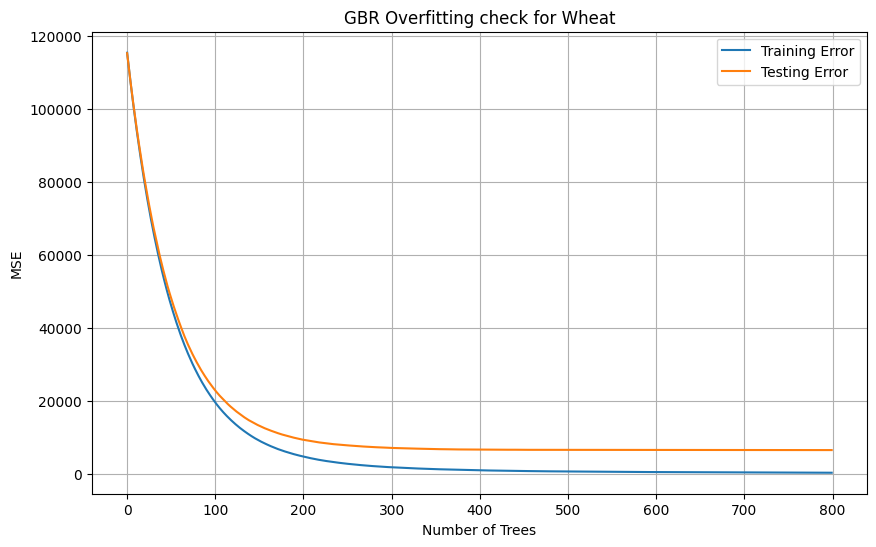

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    train_errors,
df=df.sort_values(by=["district","crop"])
    label="Training Error"
)
plt.plot(
    test_errors,
    label="Testing Error"
)
plt.xlabel("Number of Trees")
plt.ylabel("MSE")
plt.title("GBR Overfitting check for Wheat")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
import joblib
joblib.dump(gbr,"model_wheat.pkl")

['model_wheat.pkl']

In [47]:
joblib.dump(gbr,"model_wheat.pkl")

['model_wheat.pkl']

In [48]:
import joblib

feature_columns = x.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns_wheat.pkl"
)

['feature_columns_wheat.pkl']

Text(0.5, 1.0, 'Wheat Crop (Actual vs Predicted)')

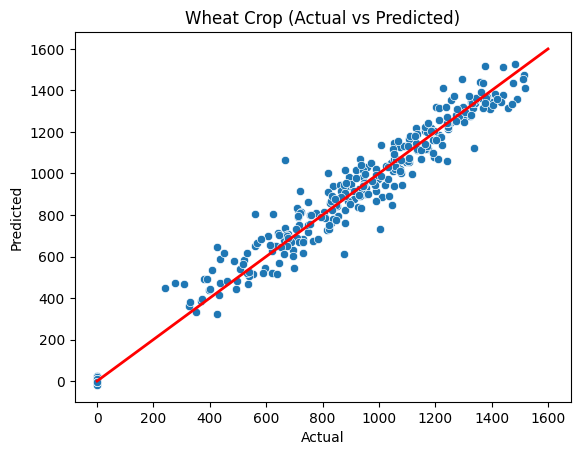

In [49]:
sns.scatterplot(x=y_test,y=gbr_pred)
plt.plot([0,1600],
         [0,1600],
         color='r',
         linestyle='-',
         linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Wheat Crop (Actual vs Predicted)")

In [50]:
import shap

/home/asad-shareef/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
exp=shap.Explainer(gbr)
shap_values=exp(x.drop("year",axis=1))

In [52]:
np.shape(shap_values.values)

(1524, 49)

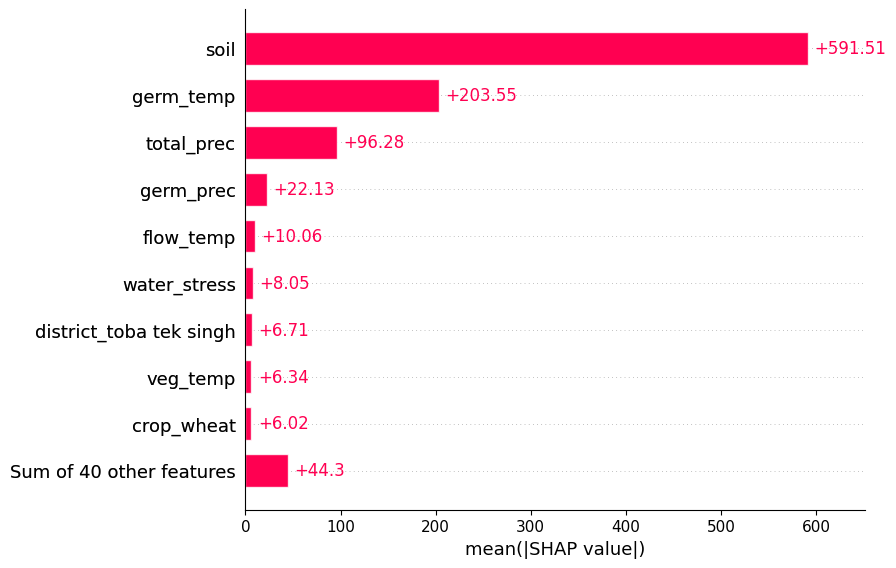

In [53]:
shap.plots.bar(shap_values)